# Junção — combustíveis entram na tabela UF × mês (T-025)

Objetivo: acrescentar a família **`comb_*`** à tabela fato do T-024, levando a
`fato_alimentos_uf_mes.parquet` de 89 para **108 colunas**, sem mexer numa linha do que já
estava lá.

**Por que combustível numa tabela sobre inflação de alimentos.** São duas pontas do mesmo problema,
e nenhuma delas está coberta pelas cinco fontes do T-024:

* **O diesel é o custo de frete de toda a comida.** Nada sai da lavoura sem caminhão, e o Brasil
  move ~65 % da sua carga por rodovia. Um choque no diesel chega ao supermercado com defasagem — e
  a §7 mede essa defasagem em **4 a 5 meses**.
* **O GLP é item da própria cesta do IPCA.** O gás de cozinha não é insumo do alimento, é o preço
  de *cozinhá-lo*, e está dentro do orçamento doméstico que o alvo mede.

E há uma terceira razão, estrutural: as colunas `macro_*` (dólar, Selic, IGP-M) são **idênticas em
todas as UFs** — explicam variação no tempo, nunca diferença entre capitais. Preço de combustível
tem as duas dimensões. O diesel do Acre custa 20 % mais que a mediana nacional, todo mês.

| | Entrada | Grão de uma linha | Chave |
|---|---|---|---|
| Fonte nova | `data/raw/combustiveis/combustivel.csv` | mês × UF × **produto** | `ano_mes` (str) |
| Testemunha | `data/raw/combustiveis/results-*.csv` | **coleta individual** (posto × dia) | — |
| Espinha | `data/processed/fato_alimentos_uf_mes.parquet` | UF × mês | `(sigla_uf, ano_mes)` |

Saída:

| Arquivo | O que é |
|---|---|
| `data/interim/combustiveis_uf_mes.parquet` | 27 UF × 267 meses, largo — a fonte tratada |
| `data/processed/fato_alimentos_combustiveis_uf_mes.parquet` | **a versão final: 2.088 × 108** |
| `outputs/tabelas/dicionario_variaveis_combustiveis.csv` | as 108 colunas documentadas |

O código está em [`src/tratamento/25_combustiveis.py`](../src/tratamento/25_combustiveis.py). Este
notebook mostra a junção acontecendo, incluindo o que ela recusa a fazer.

In [1]:
from pathlib import Path
import importlib.util
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (11, 3.6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

RAIZ = Path("..").resolve()
sys.path.insert(0, str(RAIZ))

from src.tratamento.chaves import checa_join, padroniza_chaves, valida_chaves

# 25_combustiveis.py começa com número, então não dá para `import` direto —
# mesma manobra do notebook 06 com 24_junta.py.
_spec = importlib.util.spec_from_file_location(
    "combustiveis", RAIZ / "src" / "tratamento" / "25_combustiveis.py"
)
comb = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(comb)

RAW = RAIZ / "data" / "raw" / "combustiveis"
PROCESSED = RAIZ / "data" / "processed"

JANELA = (pd.Period("2015-01", "M"), pd.Period("2026-06", "M"))
print("módulo carregado:", comb.__name__)

módulo carregado: combustiveis


---
## 1. Diagnóstico: o que a fonte é, e onde ela mente

`combustivel.csv` é o Levantamento de Preços de Combustíveis da ANP agregado por UF e mês — 26.446
linhas, 8 produtos, 27 UFs, de 2004-05 a 2026-07. A coluna `ano_mes` já veio no formato `YYYY-MM`
(a junção de `ano` + `mes` feita no passo anterior), então entra direto no contrato de chaves do
projeto.

Três coisas precisam ser medidas antes de qualquer merge: **o grão**, **a cobertura** e **quais
colunas morrem no meio da série**.

In [2]:
bruto = pd.read_csv(RAW / "combustivel.csv")
bruto_p = padroniza_chaves(bruto)

chave = ["sigla_uf", "ano_mes", "produto"]
print(f"{len(bruto):,} linhas x {bruto.shape[1]} colunas")
print(f"grão nativo: {' x '.join(chave)}")
print(f"duplicatas em {chave}: {bruto.duplicated(chave).sum():,}")
print(f"duplicatas em (sigla_uf, ano_mes): {bruto.duplicated(['sigla_uf','ano_mes']).sum():,}"
      "   <- até 8 produtos por UF-mês: o merge direto multiplicaria a espinha")
print(f"período: {bruto_p['ano_mes'].min()} a {bruto_p['ano_mes'].max()}")

26,446 linhas x 8 colunas
grão nativo: sigla_uf x ano_mes x produto
duplicatas em ['sigla_uf', 'ano_mes', 'produto']: 182
duplicatas em (sigla_uf, ano_mes): 20,649   <- até 8 produtos por UF-mês: o merge direto multiplicaria a espinha
período: 2004-05 a 2026-07


In [3]:
# Cobertura por produto DENTRO da janela do fato (2015-01 a 2026-06) e das 16 UFs do alvo.
fato_base = padroniza_chaves(pd.read_parquet(PROCESSED / "fato_alimentos_uf_mes.parquet"))
UFS_ALVO = sorted(fato_base["sigla_uf"].unique())
GRADE = len(UFS_ALVO) * 138          # 16 UFs x 138 meses = 2.208 UF-meses possíveis

janela = bruto_p[
    bruto_p["ano_mes"].between(*JANELA) & bruto_p["sigla_uf"].isin(UFS_ALVO)
]

cobertura = (
    janela.groupby("produto")
    .agg(
        linhas=("sigla_uf", "size"),
        ufs=("sigla_uf", "nunique"),
        meses=("ano_mes", "nunique"),
        primeiro=("ano_mes", "min"),
        ultimo=("ano_mes", "max"),
        preco_medio=("preco_venda_medio", "mean"),
    )
    .assign(pct_da_grade=lambda d: (d["linhas"] / GRADE * 100).round(1))
    .sort_values("pct_da_grade", ascending=False)
)
cobertura[["linhas", "ufs", "meses", "primeiro", "ultimo", "pct_da_grade", "preco_medio"]]

,linhas,ufs,meses,primeiro,ultimo,pct_da_grade,preco_medio
produto,,,,,,,
Glp,1981,16,123,2015-01,2026-06,89.70,85.53
Etanol,1695,16,105,2015-01,2026-06,76.80,4.10
Diesel S10,1696,16,105,2015-01,2026-06,76.80,5.07
Gasolina,1695,16,105,2015-01,2026-06,76.80,5.32
Diesel,1692,16,105,2015-01,2026-06,76.60,5.00
Gnv,1207,15,105,2015-01,2026-06,54.70,3.95
Gasolina Aditivada,1070,16,66,2020-10,2026-06,48.50,6.19


A tabela decide quais produtos entram. **Cinco cobrem a janela inteira nas 16 UFs**; três não:

| Produto | Por que fica de fora |
|---|---|
| `Diesel S50` | nem aparece na tabela: só existe em **2012**, 73 linhas na série toda |
| `Gasolina Aditivada` | começa em **2020-10** — metade da grade, e ~0,99 de correlação com a comum |
| `Gnv` | 55 % da grade, ausente numa UF; combustível de frota urbana leve, não move frete agrícola |

> ⚠️ **`Diesel` e `Diesel S10` são produtos diferentes e ambos ficam.** O S10 é o de baixo enxofre,
> obrigatório em veículos novos; o "comum" ainda é vendido para frota antiga. Os preços andam
> juntos mas não são o mesmo item, e a transição entre eles é gradual ao longo da série.

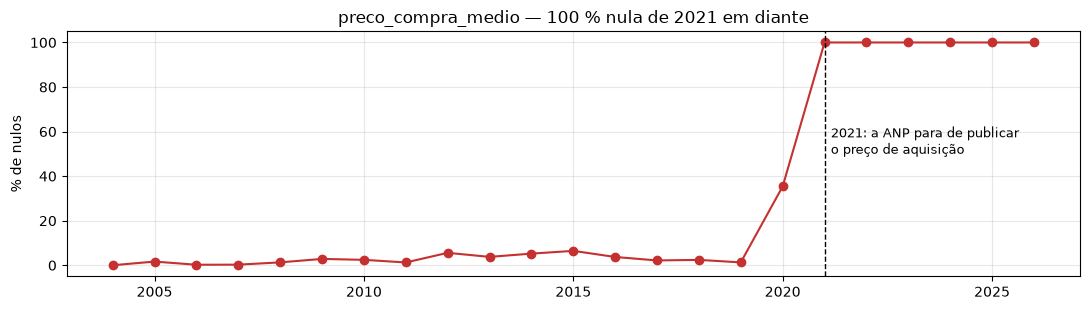

nulos no total: 47.9 %


In [4]:
# A coluna que morre no meio da série.
por_ano = bruto_p.groupby(bruto_p["ano_mes"].dt.year)
nulos_compra = por_ano["preco_compra_medio"].apply(lambda s: s.isna().mean() * 100)

fig, ax = plt.subplots(figsize=(11, 3.2))
ax.plot(nulos_compra.index, nulos_compra.values, marker="o", color="#c53030")
ax.axvline(2021, ls="--", color="black", lw=1)
ax.text(2021.15, 50, "2021: a ANP para de publicar\no preço de aquisição", fontsize=9)
ax.set_ylabel("% de nulos")
ax.set_title("preco_compra_medio — 100 % nula de 2021 em diante")
plt.tight_layout()
plt.show()

print(f"nulos no total: {bruto['preco_compra_medio'].isna().mean() * 100:.1f} %")

`preco_compra_medio` (o que o posto paga à distribuidora) é **descartada**. Uma coluna que existe
até 2020 e some depois não é uma variável com nulos — é duas séries diferentes coladas, e vira
degrau artificial em qualquer modelo que a use. Fica só `preco_venda_medio`, o preço ao
consumidor, que é o que interessa para custo de frete e para cesta doméstica de qualquer forma.

---
## 2. As três armadilhas

O T-024 documentou duas maneiras de um merge estragar dados em silêncio. Esta fonte traz uma
terceira, que é temporal e não aparece em nenhum `checa_join`.

### 2a. O grão tem `produto`: o merge direto multiplica a espinha por 5

Exatamente o problema da safra no T-024, com fator 5 em vez de 11. `checa_join()` pega.

In [5]:
espinha = fato_base[["sigla_uf", "ano_mes"]].copy()
longo = comb.consolida(comb.carrega_bruto())      # UF x mês x produto, já sem duplicata

inflado = espinha.merge(longo, on=["sigla_uf", "ano_mes"], how="left")

try:
    checa_join(espinha, inflado, "teste_fanout", ["sigla_uf", "ano_mes"], coluna_teste="preco")
except ValueError as erro:
    print(f">>> checa_join disparou:\n{erro}")

  [join] teste_fanout           on sigla_uf+ano_mes      2,088 ->  8,471 linhas | match  98.4% (preco)
>>> checa_join disparou:
[teste_fanout] o merge inflou 2,088 -> 8,471 linhas: a tabela da direita duplica ['sigla_uf', 'ano_mes']. Pivote antes de juntar.


### 2b. A média simples trata 1 posto como se fossem 5.681

**182 grupos** de `(sigla_uf, ano_mes, produto)` chegam repetidos — 364 linhas. Quase todos estão em
**2026-04**, que veio em duas levas de coleta; o resto são linhas soltas de anos antigos, com
`unidade_medida` nula e um único posto pesquisado. Um `drop_duplicates()` escolheria uma leva ao
acaso; uma média simples daria a elas o mesmo peso.

A regra é uma só e resolve os dois casos: **média ponderada por `quantidade_registros`**.

In [6]:
dups = bruto_p[bruto_p.duplicated(["sigla_uf", "ano_mes", "produto"], keep=False)]

def compara(g):
    simples = g["preco_venda_medio"].mean()
    pond = (g["preco_venda_medio"] * g["quantidade_registros"]).sum() / g["quantidade_registros"].sum()
    return pd.Series({"simples": simples, "ponderada": pond, "erro_pct": (simples / pond - 1) * 100,
                      "postos": g["quantidade_registros"].tolist()})

efeito = dups.groupby(["sigla_uf", "ano_mes", "produto"]).apply(compara, include_groups=False)
pior = efeito.reindex(efeito["erro_pct"].abs().sort_values(ascending=False).index).head(5)

print(f"{len(dups):,} linhas duplicadas em {len(efeito):,} grupos "
      f"({(dups['ano_mes'].dt.year == 2026).sum():,} delas em 2026)\n")
print("os 5 grupos onde a ponderação mais muda o preço:")
pior

364 linhas duplicadas em 182 grupos (350 delas em 2026)

os 5 grupos onde a ponderação mais muda o preço:


,,,simples,ponderada,erro_pct,postos
sigla_uf,ano_mes,produto,,,,
PA,2008-02,Glp,17.98,32.91,-45.37,"[1, 674]"
SP,2017-02,Glp,48.79,52.57,-7.20,"[3297, 1]"
RN,2018-07,Diesel,3.21,3.41,-5.94,"[1, 134]"
SC,2018-01,Glp,71.61,68.24,4.94,"[486, 1]"
MA,2010-08,Gasolina,2.73,2.66,2.88,"[1, 161]"


O pior caso é brutal: o GLP do Pará em 2008-02 sai a **R$ 17,98 na média simples contra R$ 32,91 na
ponderada** — 45 % de erro, porque um posto solto com R$ 3,00 pesa o mesmo que 674 postos com
R$ 32,95. Sempre no mesmo sentido: **o registro solto puxa o mês inteiro**. Onde as duas levas de
coleta são grandes (o caso de 2026-04), as duas médias praticamente coincidem, e é assim que tem de
ser. A ponderação não é um ajuste fino: é a diferença entre "o preço médio da UF" e "a média de
duas coisas que não são comparáveis".

### 2c. `shift(1)` sobre uma tabela com buracos inventa variação mensal

Esta é a armadilha nova, e nenhum `checa_join` a detecta — o merge está certo, o número é que é
mentira. A fonte **não tem coleta de combustível líquido em 33 dos 138 meses da janela**, e o mês
que falta, falta nas 27 UFs ao mesmo tempo.

In [7]:
sp = longo[(longo["sigla_uf"] == "SP") & (longo["produto"] == "gasolina")].sort_values("ano_mes")
sp18 = sp[sp["ano_mes"].between(pd.Period("2018-01", "M"), pd.Period("2018-12", "M"))].copy()

# O jeito ingênuo: pct_change sobre as linhas como elas vêm.
sp18["var_ingenua_pct"] = sp18["preco"].pct_change() * 100
sp18["meses_de_distancia"] = (
    sp18["ano_mes"].astype("int64").diff()
)

print("gasolina em SP, 2018 — as linhas que a fonte tem:\n")
print(sp18[["ano_mes", "preco", "var_ingenua_pct", "meses_de_distancia"]].to_string(index=False))

gasolina em SP, 2018 — as linhas que a fonte tem:

ano_mes  preco  var_ingenua_pct  meses_de_distancia
2018-01   4.04              NaN                 NaN
2018-02   4.05             0.25                1.00
2018-03   4.03            -0.49                1.00
2018-07   4.30             6.86                4.00


A última linha diz `+6,9 %` numa coluna chamada "variação mensal". São **quatro meses** de
distância: a fonte pula abril, maio e junho de 2018. O número não é um erro de cálculo, é um erro
de rótulo — e vai calado para dentro de qualquer regressão.

A defesa é calcular a variação **sobre a grade completa de meses**, não sobre as linhas existentes:
o mês ausente vira uma linha `NaN`, e a variação nasce `NaN` junto. É o que
`monta_grade()` faz antes de qualquer `shift`.

In [8]:
# O mesmo trecho, agora sobre a grade: 27 UFs x todos os meses entre o 1º e o último.
comb_largo = comb.prepara_combustiveis()

sp_grade = comb_largo[comb_largo["sigla_uf"] == "SP"]
sp_grade = sp_grade[sp_grade["ano_mes"].between(pd.Period("2018-01", "M"), pd.Period("2018-08", "M"))]

print("a mesma janela, sobre a grade — os meses sem coleta existem como linha:\n")
print(sp_grade[["ano_mes", "comb_preco_gasolina", "comb_var_mm_gasolina",
                "comb_preco_glp_13kg", "comb_observado_liquidos", "comb_observado"]]
      .to_string(index=False))

  [ok] combustivel (longo): 21,617 linhas, chave válida
a mesma janela, sobre a grade — os meses sem coleta existem como linha:

ano_mes  comb_preco_gasolina  comb_var_mm_gasolina  comb_preco_glp_13kg  comb_observado_liquidos  comb_observado
2018-01                 4.04                  2.20                65.05                     True            True
2018-02                 4.05                  0.25                64.69                     True            True
2018-03                 4.03                 -0.49                  NaN                     True            True
2018-04                  NaN                   NaN                  NaN                    False           False
2018-05                  NaN                   NaN                  NaN                    False           False
2018-06                  NaN                   NaN                  NaN                    False           False
2018-07                 4.30                   NaN                66.25         

Agosto de 2018 na última linha mostra o segundo achado do diagnóstico: **a ANP roda duas pesquisas,
não uma.** Naquele mês houve coleta de GLP e não houve de gasolina — por isso `comb_observado` é
`True` e `comb_observado_liquidos` é `False`. Os líquidos perdem 33 meses da janela; o GLP perde 15;
**só 10 meses não têm nada**. Um flag único chamaria de "observado" um mês em que o diesel não
existe, e é por isso que são dois.

---
## 3. Como a fonte virou 19 colunas

Três passos, todos em [`25_combustiveis.py`](../src/tratamento/25_combustiveis.py):

1. **`consolida()`** — média ponderada por posto, e o grão vira único em `(UF, mês, produto)`.
2. **`prepara_combustiveis()`** — pivô para largo, reindexação na grade completa, e as derivadas.
3. **`junta()`** — um `LEFT JOIN` no fato, com `checa_join` depois.

As 19 colunas, por família:

| Bloco | Colunas | O que é |
|---|---|---|
| nível | `comb_preco_{diesel, diesel_s10, gasolina, etanol, glp_13kg}` | R$/litro (o GLP, R$/botijão) |
| variação mensal | `comb_var_mm_*` | % contra o mês anterior |
| variação anual | `comb_var12_*` | % contra o mesmo mês do ano anterior |
| espacial | `comb_diesel_vs_br_pct` | desvio % da UF contra a mediana nacional do mês |
| medição | `comb_n_registros`, `comb_observado`, `comb_observado_liquidos` | quantos postos sustentam a linha; houve coleta — de qualquer produto, e de líquido |

`comb_n_registros` é o análogo de `clima_n_estacoes` do T-024: não é uma medida de preço, é o
controle de **quanta medição existe por trás dele**. Um degrau de nível que coincide com um salto
no número de postos é artefato da pesquisa, não do mercado.

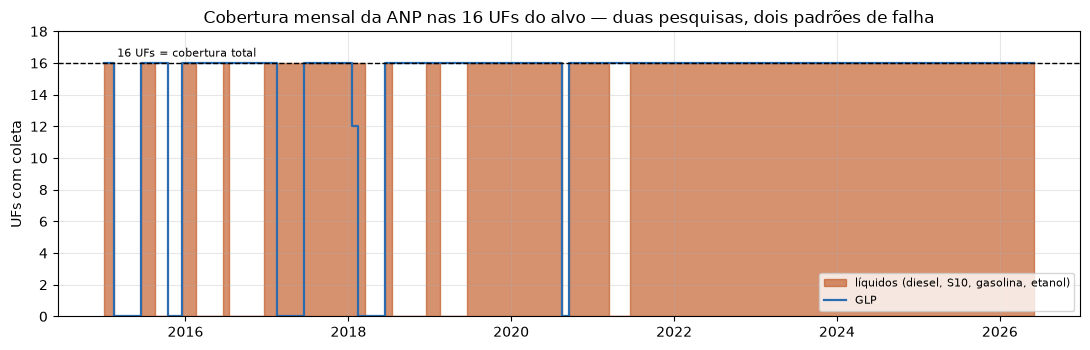

33 meses da janela sem coleta de líquidos: 2015-03, 2015-04, 2015-05, 2015-06, 2015-09, 2015-10, 2015-11, 2015-12, 2016-03, 2016-04, 2016-05, 2016-06, 2016-08, 2016-09, 2016-10, 2016-11, 2016-12, 2018-04, 2018-05, 2018-06, 2018-08, 2018-09, 2018-10, 2018-11, 2018-12, 2019-03, 2019-04, 2019-05, 2019-06, 2020-09, 2021-04, 2021-05, 2021-06
15 meses da janela sem coleta de GLP: 2015-03, 2015-04, 2015-05, 2015-06, 2015-11, 2015-12, 2017-03, 2017-04, 2017-05, 2017-06, 2018-03, 2018-04, 2018-05, 2018-06, 2020-09

10 meses sem coleta nenhuma: 2015-03, 2015-04, 2015-05, 2015-06, 2015-11, 2015-12, 2018-04, 2018-05, 2018-06, 2020-09


In [9]:
observado = comb_largo[
    comb_largo["ano_mes"].between(*JANELA) & comb_largo["sigla_uf"].isin(UFS_ALVO)
]
por_mes = observado.groupby("ano_mes").agg(
    liquidos=("comb_observado_liquidos", "sum"),
    glp=("comb_preco_glp_13kg", "count"),
)
eixo = por_mes.index.to_timestamp()

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.fill_between(eixo, por_mes["liquidos"], step="mid", color="#c05621", alpha=0.65,
                label="líquidos (diesel, S10, gasolina, etanol)")
ax.step(eixo, por_mes["glp"], where="mid", color="#2b6cb0", lw=1.6, label="GLP")
ax.axhline(16, color="black", ls="--", lw=1)
ax.text(eixo[2], 16.4, "16 UFs = cobertura total", fontsize=8)
ax.set_ylabel("UFs com coleta")
ax.set_ylim(0, 18)
ax.set_title("Cobertura mensal da ANP nas 16 UFs do alvo — duas pesquisas, dois padrões de falha")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

for rotulo, coluna in [("líquidos", "liquidos"), ("GLP", "glp")]:
    vazios = por_mes.index[por_mes[coluna] == 0]
    print(f"{len(vazios):>2} meses da janela sem coleta de {rotulo}: "
          f"{', '.join(str(m) for m in vazios)}")

sem_nada = por_mes.index[(por_mes["liquidos"] == 0) & (por_mes["glp"] == 0)]
print(f"\n{len(sem_nada)} meses sem coleta nenhuma: {', '.join(str(m) for m in sem_nada)}")

Os dois padrões de falha são nítidos: quando um mês cai, **cai inteiro** — as 16 UFs juntas, os
quatro líquidos juntos —, e o GLP falha em outros meses, porque é outra pesquisa. Dentro de um mês
que existe, a cobertura é praticamente completa.

> ⚠️ **A lacuna é da série, não de uma UF.** Uma falha de coleta de campo seria irregular entre
> estados; esta é simultânea nos 27, o que aponta para a **extração** e não para a ANP. Vale
> re-consultar a base — é a pendência nº 1 da §9.
>
> Enquanto isso, o `NaN` fica. Interpolar preencheria **23 % das linhas** com número inventado, e a
> interpolação de um preço em rampa entre março e julho de 2018 apagaria justamente o que se quer
> medir: o choque no meio. Os dois flags existem para que esse filtro seja uma linha de código.

---
## 4. A testemunha: 96.049 coletas individuais conferem o agregado

`results-20260827-153515.csv` é outra extração da mesma base, num grão totalmente diferente:
**uma linha por coleta**, com posto, município e data. A cobertura é esburacada (11 anos salteados,
551 municípios), então não serve de fonte. Serve de **testemunha**: se a média simples das coletas
de um UF-mês bate com o `preco_venda_medio` que a fonte agregada publica, a agregação é o que diz
ser.

O teste só olha UF-meses com **pelo menos 20 coletas** na amostra — abaixo disso a média amostral
é ruidosa demais para servir de referência.

In [10]:
conferencia = comb.confere_com_amostra(longo)

resumo = (
    conferencia.groupby("produto")
    .agg(
        pares=("erro_pct", "size"),
        corr=("preco", lambda s: s.corr(conferencia.loc[s.index, "preco_amostra"])),
        erro_medio_pct=("erro_pct", "mean"),
        erro_abs_mediano_pct=("erro_pct", lambda s: s.abs().median()),
    )
    .sort_values("pares", ascending=False)
)
print(f"{len(conferencia):,} UF-meses comparáveis\n")
resumo

1,149 UF-meses comparáveis



,pares,corr,erro_medio_pct,erro_abs_mediano_pct
produto,,,,
glp_13kg,512,1.00,-0.06,0.72
gasolina,241,1.00,0.12,0.52
diesel_s10,157,1.00,-0.21,0.55
etanol,134,1.00,-0.20,0.68
diesel,105,1.00,-0.20,0.53


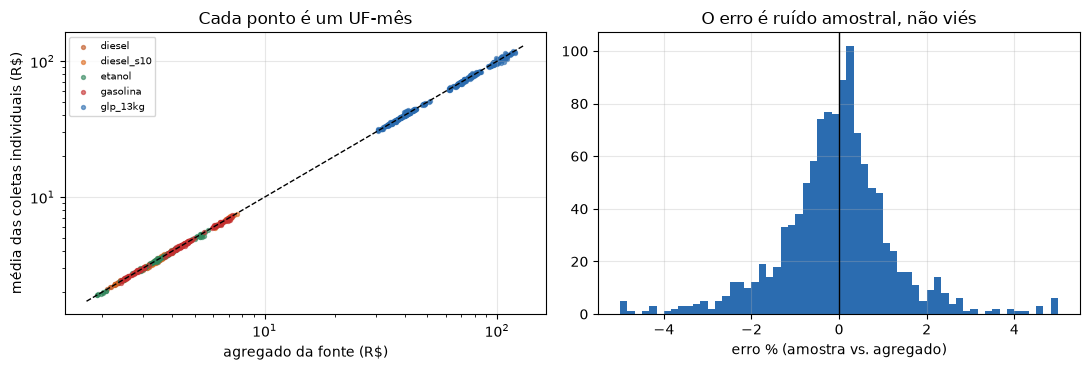

erro absoluto mediano: 0.61 %  |  viés médio: -0.07 %


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

cores = {"diesel": "#c05621", "diesel_s10": "#dd6b20", "gasolina": "#c53030",
         "etanol": "#2f855a", "glp_13kg": "#2b6cb0"}
for produto, g in conferencia.groupby("produto"):
    ax1.scatter(g["preco"], g["preco_amostra"], s=8, alpha=0.6,
                color=cores[produto], label=produto)
lims = [conferencia["preco"].min() * 0.9, conferencia["preco"].max() * 1.1]
ax1.plot(lims, lims, color="black", lw=1, ls="--")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.set_xlabel("agregado da fonte (R$)"); ax1.set_ylabel("média das coletas individuais (R$)")
ax1.set_title("Cada ponto é um UF-mês")
ax1.legend(fontsize=7)

ax2.hist(conferencia["erro_pct"].clip(-5, 5), bins=60, color="#2b6cb0")
ax2.axvline(0, color="black", lw=1)
ax2.set_xlabel("erro % (amostra vs. agregado)")
ax2.set_title("O erro é ruído amostral, não viés")
plt.tight_layout()
plt.show()

print(f"erro absoluto mediano: {conferencia['erro_pct'].abs().median():.2f} %  |  "
      f"viés médio: {conferencia['erro_pct'].mean():+.2f} %")

Correlação acima de **0,993** em todos os produtos e erro absoluto mediano de **0,6 %**, sem viés
de sinal. Duas extrações independentes, grãos diferentes, mesmo número — a agregação da fonte está
validada. É o mesmo tipo de checagem que o T-024 fez com os eventos históricos, só que aqui existe
uma segunda medição para confrontar.

---
## 5. A junção

A espinha aqui **não é o calendário completo**: é a tabela fato do T-024, já filtrada nas 16 UFs
com alvo. A regra do T-024 continua valendo — `LEFT JOIN`, `validate="m:1"`, `checa_join` depois —
mas a direção mudou: o T-024 montou a espinha e pendurou fontes nela; o T-025 pendura uma fonte
numa espinha que já existe. Nenhuma linha do fato pode entrar, sair ou mudar de valor.

In [12]:
fato = comb.junta()


[1] Espinha — o fato do T-024
  [ok] fato_alimentos_uf_mes: 2,088 linhas, chave válida

[2] Combustíveis


  [ok] combustivel (longo): 21,617 linhas, chave válida
  [ok] combustiveis_uf_mes: 7,209 linhas, chave válida

[3] LEFT JOIN
  [join] combustiveis           on sigla_uf+ano_mes      2,088 ->  2,088 linhas | match  77.1% (comb_preco_diesel)


In [13]:
novas = [c for c in fato.columns if c.startswith("comb_")]

print(f"{fato_base.shape[1]} colunas -> {fato.shape[1]} colunas ({len(novas)} novas)")
print(f"linhas: {len(fato_base):,} -> {len(fato):,}   (o LEFT JOIN preservou a espinha)")

iguais = fato_base.equals(fato[fato_base.columns])
print(f"as 89 colunas do T-024 saíram intactas: {iguais}")

# A decomposição da taxa de match: meses que existem x UFs, contra o que veio.
meses_com_diesel = fato.loc[fato["comb_preco_diesel"].notna(), "ano_mes"].nunique()
possiveis = meses_com_diesel * fato["sigla_uf"].nunique()
print(f"\ndiesel: {meses_com_diesel} dos 138 meses têm coleta -> {possiveis:,} UF-meses possíveis, "
      f"{fato['comb_preco_diesel'].notna().sum():,} preenchidos "
      f"({fato['comb_preco_diesel'].notna().sum() / possiveis * 100:.1f} % do possível)")

inventario = pd.DataFrame({
    "dtype": fato[novas].dtypes.astype(str).values,
    "nao_nulos": fato[novas].notna().sum().values,
    "pct_nulos": (fato[novas].isna().mean() * 100).round(1).values,
    "exemplo": [fato[c].dropna().iloc[0] for c in novas],
}, index=novas)
inventario

89 colunas -> 108 colunas (19 novas)
linhas: 2,088 -> 2,088   (o LEFT JOIN preservou a espinha)
as 89 colunas do T-024 saíram intactas: True

diesel: 105 dos 138 meses têm coleta -> 1,680 UF-meses possíveis, 1,610 preenchidos (95.8 % do possível)


,dtype,nao_nulos,pct_nulos,exemplo
comb_preco_diesel,float64,1610,22.90,4.21
comb_preco_diesel_s10,float64,1614,22.70,4.26
comb_preco_etanol,float64,1613,22.70,4.00
comb_preco_gasolina,float64,1613,22.70,5.08
comb_preco_glp_13kg,float64,1882,9.90,78.59
comb_n_registros,float64,1949,6.70,452.00
comb_var_mm_diesel,float64,1463,29.90,-0.71
comb_var12_diesel,float64,1269,39.20,10.79
comb_var_mm_diesel_s10,float64,1469,29.60,-0.59
comb_var12_diesel_s10,float64,1276,38.90,11.90


Taxa de match de **77,1 %** no diesel, e o número se decompõe inteiro: dos 138 meses da janela,
105 têm coleta de líquido — 105 × 16 UFs = 1.680 linhas possíveis, das quais 1.610 vêm preenchidas.
As 70 que faltam são UF-meses isolados dentro de meses que existem. Ou seja: **95,8 % do que era
possível casar, casou**; o resto é a lacuna temporal da §3, não uma UF que a fonte não cobre.

---
## 6. Perfil de nulos — e o que este vazio quer dizer

A regra do projeto continua: **nenhum `NaN` vira 0**, e todo vazio ganha justificativa escrita no
dicionário.

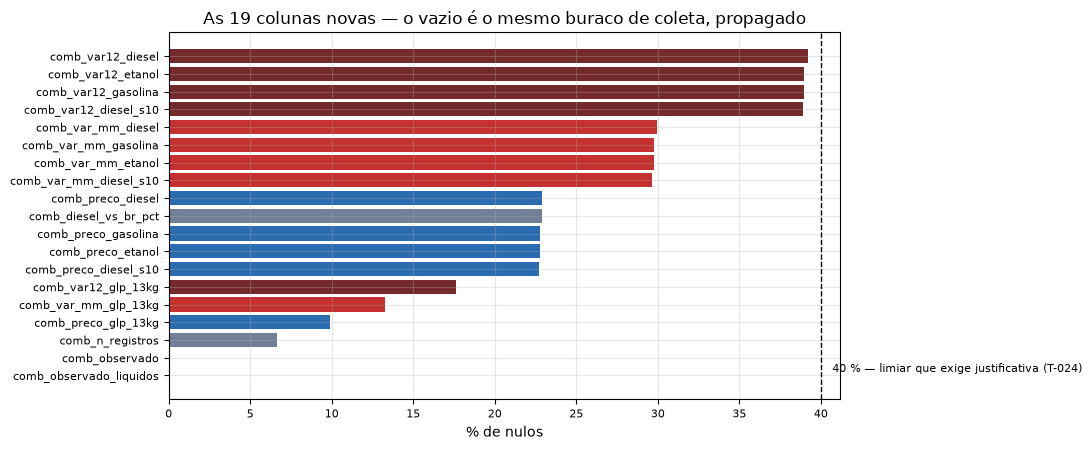

In [14]:
nulos = (fato[novas].isna().mean() * 100).sort_values()

cores_bloco = []
for c in nulos.index:
    if c.startswith("comb_var12"):
        cores_bloco.append("#742a2a")
    elif c.startswith("comb_var_mm"):
        cores_bloco.append("#c53030")
    elif c.startswith("comb_preco"):
        cores_bloco.append("#2b6cb0")
    else:
        cores_bloco.append("#718096")

fig, ax = plt.subplots(figsize=(11, 4.6))
ax.barh(nulos.index, nulos.values, color=cores_bloco)
ax.axvline(40, color="black", ls="--", lw=1)
ax.text(40.7, 0.2, "40 % — limiar que exige justificativa (T-024)", fontsize=8)
ax.set_xlabel("% de nulos")
ax.set_title("As 19 colunas novas — o vazio é o mesmo buraco de coleta, propagado")
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()

Os três patamares são o mesmo buraco visto três vezes, e a escada é aritmética, não acidental:

| Bloco | % de nulos | Por quê |
|---|---|---|
| `comb_preco_*` (líquidos) | ~23 % | os 33 meses sem coleta |
| `comb_preco_glp_13kg` | 9,9 % | o GLP tem pesquisa própria e só perde 15 meses, não 33 |
| `comb_var_mm_*` | ~30 % | precisa de **dois** meses seguidos: perde o buraco e a borda dele |
| `comb_var12_*` | ~39 % | precisa do mês e do mesmo mês do ano anterior: perde os dois buracos |

> ⚠️ **`NaN` em `comb_*` significa MÊS SEM PESQUISA — nunca "preço zero" nem "combustível
> indisponível".** Um `fillna(0)` aqui criaria postos vendendo diesel de graça em 23 % da amostra.
> A leitura correta é `fato[fato["comb_observado_liquidos"]]` para os líquidos (e `comb_observado`
> para o GLP), e as colunas acima de 39 % têm a justificativa gravada no dicionário.

---
## 7. Validações — estruturais, e depois históricas

As estruturais garantem que a tabela está bem formada. As históricas testam se ela **reconhece
coisas que sabemos que aconteceram** — é o que separa uma junção que roda de uma junção correta.

In [15]:
liquidos = [c for c in novas if c.startswith("comb_preco_") and "glp" not in c]

checagens = [
    ("chave (sigla_uf, ano_mes) continua única",
     fato.duplicated(["sigla_uf", "ano_mes"]).sum() == 0),
    ("2.088 linhas, 16 UFs, 138 meses — a espinha não mexeu",
     (len(fato), fato["sigla_uf"].nunique(), fato["ano_mes"].nunique()) == (2088, 16, 138)),
    ("as 89 colunas do T-024 estão idênticas",
     fato_base.equals(fato[fato_base.columns])),
    ("ano_mes segue Period[M]", isinstance(fato["ano_mes"].dtype, pd.PeriodDtype)),
    ("combustível líquido entre 1 e 15 R$/l",
     fato[liquidos].stack().dropna().between(1, 15).all()),
    ("GLP entre 20 e 200 R$/botijão",
     fato["comb_preco_glp_13kg"].dropna().between(20, 200).all()),
    ("há deflação de combustível na série (2023 teve)",
     (fato["comb_var12_diesel"] < 0).sum() > 0),
    ("comb_observado_liquidos == False implica preço de líquido nulo",
     fato.loc[~fato["comb_observado_liquidos"], liquidos].isna().all().all()),
    ("os dois flags não são a mesma coluna (GLP falha em outros meses)",
     not fato["comb_observado"].equals(fato["comb_observado_liquidos"])),
]
pd.DataFrame(checagens, columns=["checagem", "passou"]).set_index("checagem")

,passou
checagem,
"chave (sigla_uf, ano_mes) continua única",True
"2.088 linhas, 16 UFs, 138 meses — a espinha não mexeu",True
as 89 colunas do T-024 estão idênticas,True
ano_mes segue Period[M],True
combustível líquido entre 1 e 15 R$/l,True
GLP entre 20 e 200 R$/botijão,True
há deflação de combustível na série (2023 teve),True
comb_observado_liquidos == False implica preço de líquido nulo,True
os dois flags não são a mesma coluna (GLP falha em outros meses),True


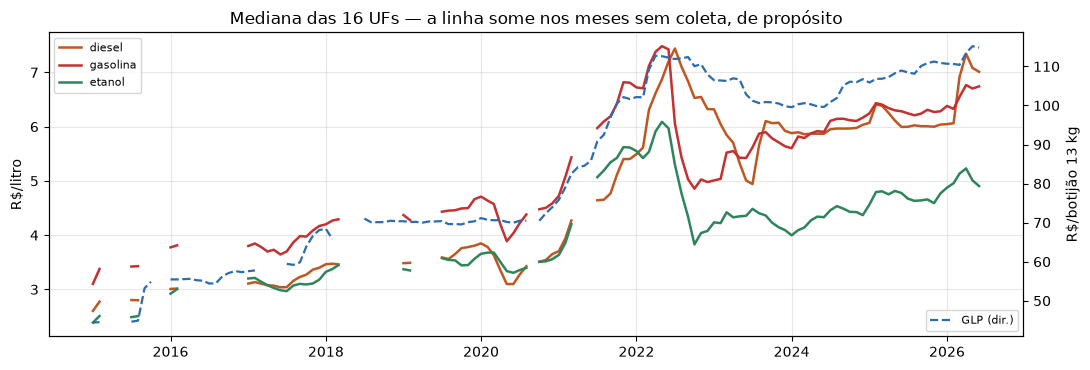

pico do diesel em 12 meses: 2022-07 com +62.1 %
vale: 2023-07 com -33.8 %


In [16]:
# Validação histórica 1 — o choque de 2022 e a deflação de 2023.
nacional = fato.groupby("ano_mes")[
    ["comb_preco_diesel", "comb_preco_gasolina", "comb_preco_etanol",
     "comb_preco_glp_13kg", "comb_var12_diesel"]
].median()
eixo = nacional.index.to_timestamp()

fig, ax1 = plt.subplots(figsize=(11, 3.8))
ax1.plot(eixo, nacional["comb_preco_diesel"], color="#c05621", lw=1.8, label="diesel")
ax1.plot(eixo, nacional["comb_preco_gasolina"], color="#c53030", lw=1.8, label="gasolina")
ax1.plot(eixo, nacional["comb_preco_etanol"], color="#2f855a", lw=1.8, label="etanol")
ax1.set_ylabel("R$/litro")
ax1.legend(loc="upper left", fontsize=8)

ax2 = ax1.twinx()
ax2.plot(eixo, nacional["comb_preco_glp_13kg"], color="#2b6cb0", lw=1.6, ls="--", label="GLP (dir.)")
ax2.set_ylabel("R$/botijão 13 kg")
ax2.grid(False)
ax2.legend(loc="lower right", fontsize=8)
ax1.set_title("Mediana das 16 UFs — a linha some nos meses sem coleta, de propósito")
plt.tight_layout()
plt.show()

pico = nacional["comb_var12_diesel"].idxmax()
vale = nacional["comb_var12_diesel"].idxmin()
print(f"pico do diesel em 12 meses: {pico} com {nacional['comb_var12_diesel'].max():+.1f} %")
print(f"vale: {vale} com {nacional['comb_var12_diesel'].min():+.1f} %")
assert pd.Period("2022-01", "M") <= pico <= pd.Period("2022-12", "M")
assert nacional["comb_var12_diesel"].min() < -20

O pico de **+62 % em 12 meses em julho de 2022** e o vale de **−34 % em 2023** são os dois lados do
mesmo episódio: a alta do petróleo pós-invasão da Ucrânia, seguida do corte de tributos federais
sobre combustíveis em junho/2022 e da base de comparação alta que veio depois. A série reconhece
os dois sem que ninguém tenha dito a ela que existiram.

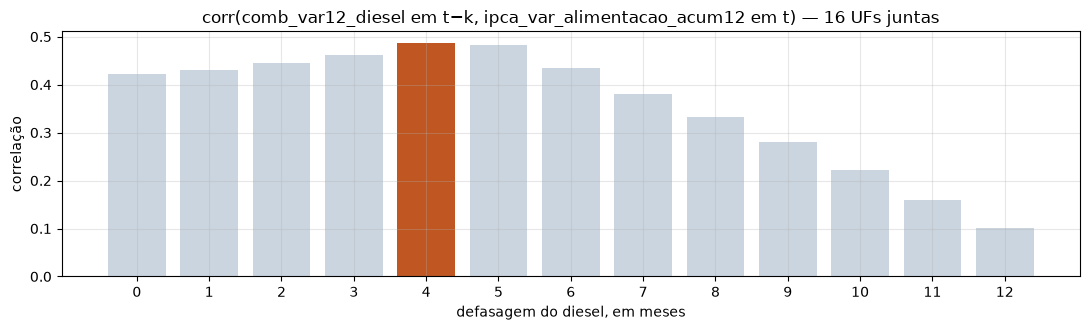

máximo em k = 4 meses, corr = 0.487 (contra 0.422 sem defasagem)


In [17]:
# Validação histórica 2 — a defasagem. O diesel de hoje explica a comida de quando?
fato_ord = fato.sort_values(["sigla_uf", "ano_mes"])
defasagens = range(0, 13)
correls = [
    fato_ord.groupby("sigla_uf")["comb_var12_diesel"].shift(k).corr(
        fato_ord["ipca_var_alimentacao_acum12"]
    )
    for k in defasagens
]
melhor = int(np.argmax(correls))

fig, ax = plt.subplots(figsize=(11, 3.4))
ax.bar(list(defasagens), correls,
       color=["#c05621" if k == melhor else "#cbd5e0" for k in defasagens])
ax.set_xlabel("defasagem do diesel, em meses")
ax.set_ylabel("correlação")
ax.set_title("corr(comb_var12_diesel em t−k, ipca_var_alimentacao_acum12 em t) — 16 UFs juntas")
ax.set_xticks(list(defasagens))
plt.tight_layout()
plt.show()

print(f"máximo em k = {melhor} meses, corr = {correls[melhor]:.3f} "
      f"(contra {correls[0]:.3f} sem defasagem)")
assert 2 <= melhor <= 8, "a defasagem saiu fora da faixa plausível de repasse ao varejo"

**Este é o gráfico que justifica a família existir.** A correlação sobe de 0,42 sem defasagem para
**0,49 com o diesel adiantado em 4 meses**, e cai monotonicamente depois — a forma de um repasse de
custo, não de uma coincidência. Quatro a cinco meses é a ordem de grandeza que a literatura de
repasse de frete ao varejo alimentar registra.

É também o motivo de a tabela guardar **nível e variação** em vez de só o nível: a defasagem se
mede na variação, e o modelo que quiser usá-la vai precisar dos `shift` que as features de lag
(T-023) constroem.

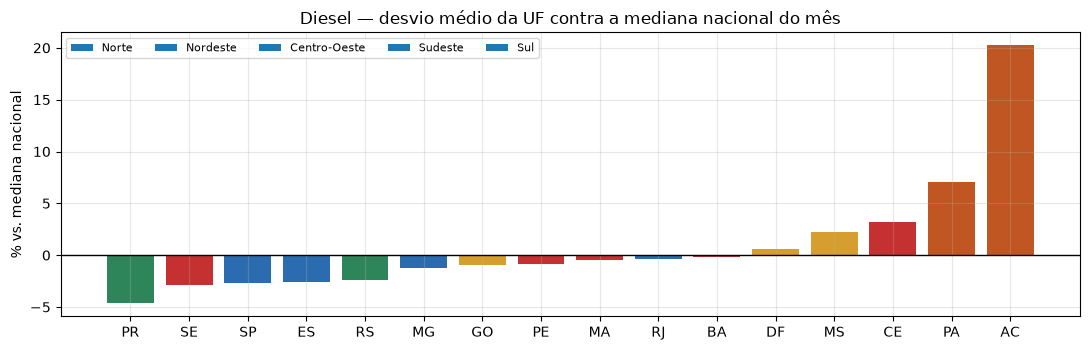

sigla_uf
PR   -4.70
SE   -2.90
SP   -2.70
ES   -2.50
RS   -2.40
MG   -1.30
GO   -1.00
PE   -0.80
MA   -0.50
RJ   -0.40
BA   -0.20
DF    0.60
MS    2.20
CE    3.20
PA    7.10
AC   20.30


In [18]:
# Validação histórica 3 — a dimensão que as colunas macro_* não têm: espaço.
espacial = (
    fato.groupby(["sigla_uf", "regiao"])["comb_diesel_vs_br_pct"]
    .mean()
    .reset_index()
    .sort_values("comb_diesel_vs_br_pct")
)
cores_regiao = {"Norte": "#c05621", "Nordeste": "#c53030", "Centro-Oeste": "#d69e2e",
                "Sudeste": "#2b6cb0", "Sul": "#2f855a"}

fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(espacial["sigla_uf"], espacial["comb_diesel_vs_br_pct"],
       color=[cores_regiao[r] for r in espacial["regiao"]])
ax.axhline(0, color="black", lw=1)
ax.set_ylabel("% vs. mediana nacional")
ax.set_title("Diesel — desvio médio da UF contra a mediana nacional do mês")
for regiao, cor in cores_regiao.items():
    ax.bar([], [], color=cor, label=regiao)
ax.legend(fontsize=8, ncol=5)
plt.tight_layout()
plt.show()

print(espacial.set_index("sigla_uf")["comb_diesel_vs_br_pct"].round(1).to_string())

O Acre paga **20 % a mais** pelo diesel que a mediana do país, todo mês da série; o Paraná paga 5 %
a menos. É distância de refinaria e custo de escoamento, e é exatamente o tipo de diferença que
`macro_dolar_ptax_medio` — idêntica nas 16 UFs — não consegue explicar. Uma regressão do alvo com
efeito fixo de UF absorve esse nível; uma sem efeito fixo agora tem a coluna para usar.

---
## 8. A tabela final e o dicionário

`data/processed/fato_alimentos_combustiveis_uf_mes.parquet` — **2.088 linhas × 108 colunas**, chave
`(sigla_uf, ano_mes)`, seis fontes: IBGE/SIDRA, IBGE/LSPA, INMET, ANA, BCB e agora ANP.

In [19]:
final = padroniza_chaves(pd.read_parquet(PROCESSED / "fato_alimentos_combustiveis_uf_mes.parquet"))

familias = (
    final.columns.to_series()
    .str.extract(r"^(ipca|clima|safra|seca|macro|comb)_")[0]
    .fillna("chave")
    .value_counts()
    .rename_axis("familia")
)
print(f"{len(final):,} linhas x {final.shape[1]} colunas  |  "
      f"{final.memory_usage(deep=True).sum() / 1e6:.1f} MB em memória\n")
print("colunas por família:")
print(familias.to_string())

2,088 linhas x 108 colunas  |  1.8 MB em memória

colunas por família:
familia
ipca     36
safra    22
comb     19
clima    11
seca      9
chave     6
macro     5


In [20]:
final[["sigla_uf", "ano_mes", "ipca_var_alimentacao_acum12", "comb_preco_diesel",
       "comb_var12_diesel", "comb_preco_glp_13kg", "comb_diesel_vs_br_pct",
       "comb_n_registros", "comb_observado_liquidos"]].tail(8)

,sigla_uf,ano_mes,ipca_var_alimentacao_acum12,comb_preco_diesel,comb_var12_diesel,comb_preco_glp_13kg,comb_diesel_vs_br_pct,comb_n_registros,comb_observado_liquidos
2080,SP,2025-11,4.98,6.00,0.93,110.73,-0.92,"15,983.00",True
2081,SP,2025-12,3.54,6.03,0.49,110.45,-0.80,"19,425.00",True
2082,SP,2026-01,2.91,6.05,0.29,110.51,-1.08,"16,565.00",True
2083,SP,2026-02,3.27,6.06,-4.42,110.12,-0.88,"16,923.00",True
2084,SP,2026-03,3.19,6.99,10.35,110.31,0.00,"19,870.00",True
2085,SP,2026-04,3.34,7.38,18.73,113.71,-0.02,"14,403.00",True
2086,SP,2026-05,4.72,6.93,13.98,115.45,-2.76,"13,229.00",True
2087,SP,2026-06,4.52,6.78,13.01,115.26,-3.90,"20,224.00",True


In [21]:
DICIONARIO = pd.read_csv(RAIZ / "outputs" / "tabelas" / "dicionario_variaveis_combustiveis.csv")

print(f"{len(DICIONARIO)} colunas documentadas "
      f"({(DICIONARIO['coluna'].str.startswith('comb_')).sum()} novas)\n")

with pd.option_context("display.max_rows", None, "display.max_colwidth", 80, "display.width", None):
    display(
        DICIONARIO[DICIONARIO["coluna"].str.startswith("comb_")]
        [["coluna", "unidade", "fonte", "granularidade_nativa", "pct_nulos", "descricao"]]
        .set_index("coluna")
    )

108 colunas documentadas (19 novas)



,unidade,fonte,granularidade_nativa,pct_nulos,descricao
coluna,,,,,
comb_preco_diesel,R$/litro,ANP (Levantamento de Preços de Combustíveis),UF × mês × produto,22.89,"preço médio de venda ao consumidor de diesel comum, média ponderada pelo nº ..."
comb_preco_diesel_s10,R$/litro,ANP (Levantamento de Preços de Combustíveis),UF × mês × produto,22.70,"preço médio de venda ao consumidor de diesel S10, média ponderada pelo nº de..."
comb_preco_etanol,R$/litro,ANP (Levantamento de Preços de Combustíveis),UF × mês × produto,22.75,"preço médio de venda ao consumidor de etanol hidratado, média ponderada pelo..."
comb_preco_gasolina,R$/litro,ANP (Levantamento de Preços de Combustíveis),UF × mês × produto,22.75,"preço médio de venda ao consumidor de gasolina comum, média ponderada pelo n..."
comb_preco_glp_13kg,R$/botijão 13 kg,ANP (Levantamento de Preços de Combustíveis),UF × mês × produto,9.87,"preço médio de venda ao consumidor de GLP (gás de cozinha, botijão de 13 kg)..."
comb_n_registros,postos-coleta,ANP (Levantamento de Preços de Combustíveis),UF × mês × produto,6.66,"quantas coletas de preço sustentam a linha, somadas sobre os 5 produtos — co..."
comb_var_mm_diesel,%,ANP (Levantamento de Preços de Combustíveis),UF × mês × produto,29.93,variação % do preço de diesel comum contra o mês imediatamente anterior; NaN...
comb_var12_diesel,%,ANP (Levantamento de Preços de Combustíveis),UF × mês × produto,39.22,variação % do preço de diesel comum contra o mesmo mês do ano anterior; NaN ...
comb_var_mm_diesel_s10,%,ANP (Levantamento de Preços de Combustíveis),UF × mês × produto,29.65,variação % do preço de diesel S10 contra o mês imediatamente anterior; NaN q...


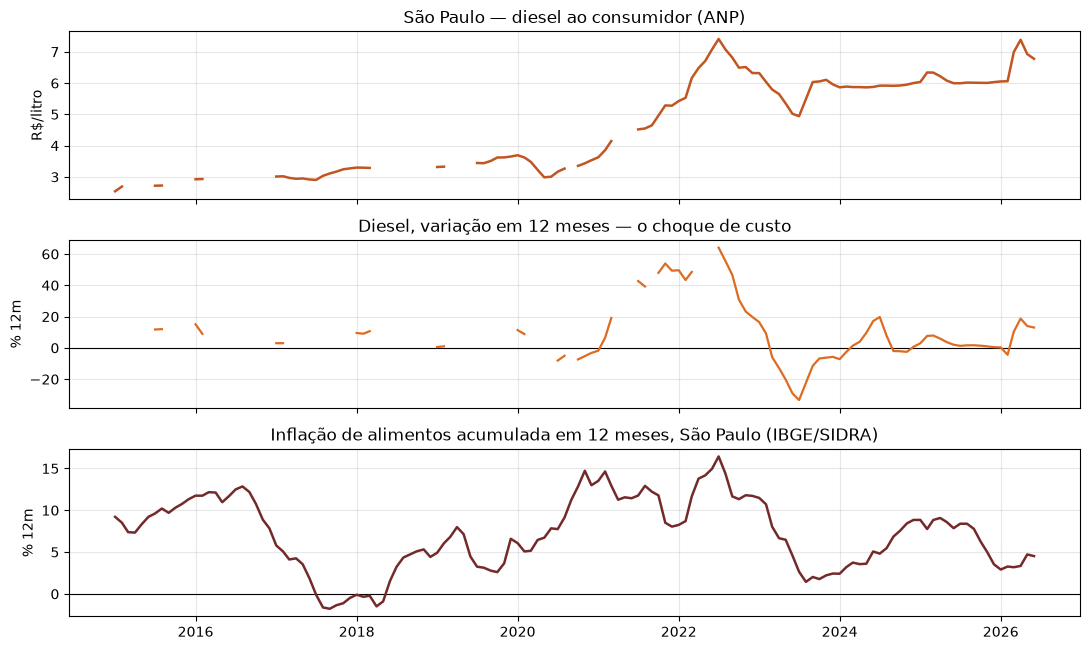

In [22]:
# As três fontes na mesma UF: o teste de que a junção faz sentido, não só de que roda.
sp = final[final["sigla_uf"] == "SP"].set_index("ano_mes")
eixo = sp.index.to_timestamp()

fig, axes = plt.subplots(3, 1, figsize=(11, 6.6), sharex=True)
axes[0].plot(eixo, sp["comb_preco_diesel"], color="#c05621", lw=1.8)
axes[0].set_ylabel("R$/litro")
axes[0].set_title("São Paulo — diesel ao consumidor (ANP)")

axes[1].axhline(0, color="black", lw=0.8)
axes[1].plot(eixo, sp["comb_var12_diesel"], color="#dd6b20", lw=1.6)
axes[1].set_ylabel("% 12m")
axes[1].set_title("Diesel, variação em 12 meses — o choque de custo")

axes[2].axhline(0, color="black", lw=0.8)
axes[2].plot(eixo, sp["ipca_var_alimentacao_acum12"], color="#742a2a", lw=1.8)
axes[2].set_ylabel("% 12m")
axes[2].set_title("Inflação de alimentos acumulada em 12 meses, São Paulo (IBGE/SIDRA)")
plt.tight_layout()
plt.show()

O painel do meio sobe primeiro; o de baixo repete a forma alguns meses depois, com amplitude menor.
É a mesma defasagem de 4 meses da §7, agora numa UF só e sem estatística nenhuma — só os dois eixos
alinhados.

---
## 9. O que dá e o que não dá para fazer com as colunas novas

| Dá para | Não dá para |
|---|---|
| Usar `comb_var12_diesel` defasado 4-5 meses como preditor do alvo | Ler `NaN` como preço zero — é **mês sem pesquisa** |
| Comparar o nível de preço **entre UFs** no mesmo mês | Comparar `comb_preco_glp_13kg` com os outros preços: unidade diferente (botijão × litro) |
| Explicar diferença **entre capitais** com `comb_diesel_vs_br_pct` | Usar `comb_var_mm_*` sem checar `comb_observado_liquidos`: 30 % das linhas não têm o mês anterior |
| Somar diesel + diesel S10 numa média de "diesel" ponderada por `comb_n_registros` | Somar os cinco preços num "índice de combustível" — misturaria litro com botijão |
| Rodar a série toda com `dropna()` nas colunas comb_* | Interpolar os 33 meses sem coleta e não dizer que interpolou |

### O que ficou pendente

1. **Fechar a lacuna de 33 meses.** A falha é da extração, não da coleta da ANP — uma nova consulta
   à base provavelmente devolve os meses faltantes e leva a cobertura de 77 % para perto de 100 %.
2. **Gasolina aditivada e GNV** entram acrescentando duas linhas ao dicionário `PRODUTOS` de
   `25_combustiveis.py` — vale a pena se alguém decidir que um recorte a partir de 2021 rende mais
   que a série longa.
3. **`comb_preco_compra`** só volta se alguém quiser modelar margem de revenda até 2020 — e aí é
   uma tabela à parte, não uma coluna desta.